In [1]:
import numpy as np
import scanpy as sc
from scipy.sparse import issparse

# -----------------------------
# Config
# -----------------------------
PATH = "/work3/s252608/DL_project/data/processed/bulk_normalized_x_input.h5ad"
BATCH_SIZE = 512

# -----------------------------
# Open in backed mode (low RAM)
# -----------------------------
adata = sc.read_h5ad(PATH, backed="r")

n_obs, n_vars = adata.shape
print(f"Shape: {n_obs:,} samples × {n_vars:,} genes")

# -----------------------------
# Streaming variance computation
# Welford online algorithm
# -----------------------------
mean = np.zeros(n_vars, dtype=np.float64)
M2 = np.zeros(n_vars, dtype=np.float64)
count = 0

for start in range(0, n_obs, BATCH_SIZE):
    end = min(start + BATCH_SIZE, n_obs)

    X_batch = adata.X[start:end]

    if issparse(X_batch):
        X_batch = X_batch.toarray()

    X_batch = np.asarray(X_batch, dtype=np.float64)

    for x in X_batch:
        count += 1
        delta = x - mean
        mean += delta / count
        delta2 = x - mean
        M2 += delta * delta2

    print(f"{end:,}/{n_obs:,}", end="\r")

variance = M2 / (count - 1)
std = np.sqrt(variance)

print("\nDone.")

# -----------------------------
# Summary statistics
# -----------------------------
print("\nVariance summary:")
print(f"Mean variance:   {variance.mean():.4f}")
print(f"Median variance: {np.median(variance):.4f}")
print(f"Min variance:    {variance.min():.4f}")
print(f"Max variance:    {variance.max():.4f}")

print("\nStd summary:")
print(f"Mean std:        {std.mean():.4f}")
print(f"Median std:      {np.median(std):.4f}")

Shape: 19,882 samples × 2,204 genes
19,882/19,882
Done.

Variance summary:
Mean variance:   0.2720
Median variance: 0.1987
Min variance:    0.0004
Max variance:    4.1202

Std summary:
Mean std:        0.4743
Median std:      0.4458


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

QC_PATH = Path("/work3/s252608/DL_project/data/qc/bulk_processed_qc_relaxed_labels.csv")
OUT_DIR = Path("/work3/s252608/DL_project/results/qc_figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

qc = pd.read_csv(QC_PATH)

# -----------------------------
# Dataset-level numbers
# -----------------------------
INITIAL_GENES = 45263
F1_RETAINED = len(qc)
F1_REMOVED = INITIAL_GENES - F1_RETAINED

print("Initial genes:", INITIAL_GENES)
print("After F1 genes:", F1_RETAINED)
print("Removed at F1:", F1_REMOVED)


# -----------------------------
# Sequential attrition table
# -----------------------------
def attrition_from_fail_reason(df, pass_col, fail_col, label):
    total_after_f1 = len(df)
    rows = []

    rows.append({
        "setting": label,
        "filter": "Initial genes",
        "retained": INITIAL_GENES,
        "removed_at_filter": 0,
    })

    rows.append({
        "setting": label,
        "filter": "F1: >=2 isoforms",
        "retained": total_after_f1,
        "removed_at_filter": F1_REMOVED,
    })

    current = total_after_f1

    filter_order = [
        ("F2_n_both_detected", "F2: >=50 both-detected samples"),
        ("F3_median_ratio", "F3: median(sumTx/gene) <= 1.5"),
        ("F4_corr", "F4: corr(gene, sumTx) threshold"),
        ("F5_low_active", "F5: >=20 active samples"),
        ("F5_dominant", "F6: mean dominant isoform <= 0.9"),
    ]

    for reason, pretty in filter_order:
        removed = int((df[fail_col] == reason).sum())
        current -= removed
        rows.append({
            "setting": label,
            "filter": pretty,
            "retained": current,
            "removed_at_filter": removed,
        })

    rows.append({
        "setting": label,
        "filter": "Final passed QC",
        "retained": int(df[pass_col].sum()),
        "removed_at_filter": 0,
    })

    return pd.DataFrame(rows)


strict_attrition = attrition_from_fail_reason(
    qc,
    pass_col="qc_pass",
    fail_col="fail_reason",
    label="strict_corr_0.8",
)

relaxed_attrition = attrition_from_fail_reason(
    qc,
    pass_col="qc_pass_relaxed",
    fail_col="fail_reason_relaxed",
    label="relaxed_corr_0.6",
)

attrition = pd.concat([strict_attrition, relaxed_attrition], ignore_index=True)

display(attrition)

attrition.to_csv(OUT_DIR / "qc_filter_attrition_table.csv", index=False)
print("Saved:", OUT_DIR / "qc_filter_attrition_table.csv")

Initial genes: 45263
After F1 genes: 19951
Removed at F1: 25312


,setting,filter,retained,removed_at_filter
0,strict_corr_0.8,Initial genes,45263,0
1,strict_corr_0.8,F1: >=2 isoforms,19951,25312
2,strict_corr_0.8,F2: >=50 both-detected samples,19951,0
3,strict_corr_0.8,F3: median(sumTx/gene) <= 1.5,11264,8687
4,strict_corr_0.8,"F4: corr(gene, sumTx) threshold",1385,9879
5,strict_corr_0.8,F5: >=20 active samples,1385,0
6,strict_corr_0.8,F6: mean dominant isoform <= 0.9,1279,106
7,strict_corr_0.8,Final passed QC,1279,0
8,relaxed_corr_0.6,Initial genes,45263,0
9,relaxed_corr_0.6,F1: >=2 isoforms,19951,25312


Saved: /work3/s252608/DL_project/results/qc_figures/qc_filter_attrition_table.csv


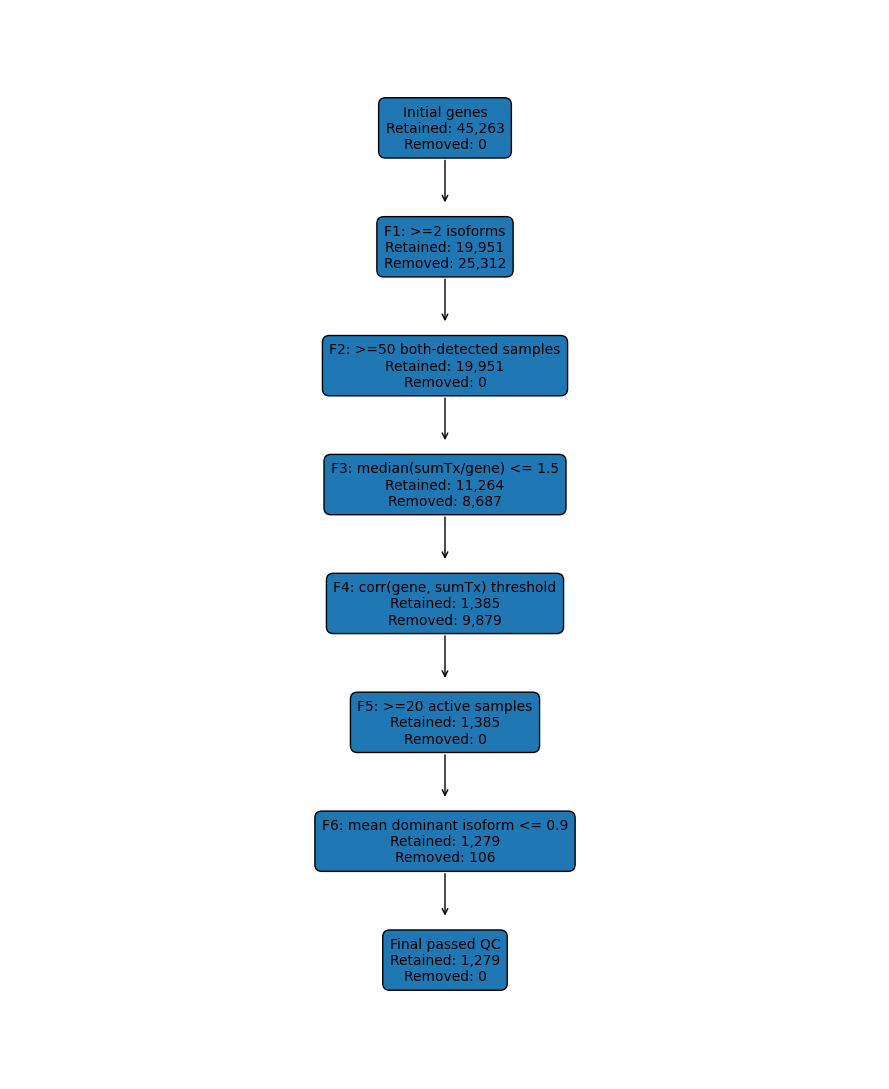

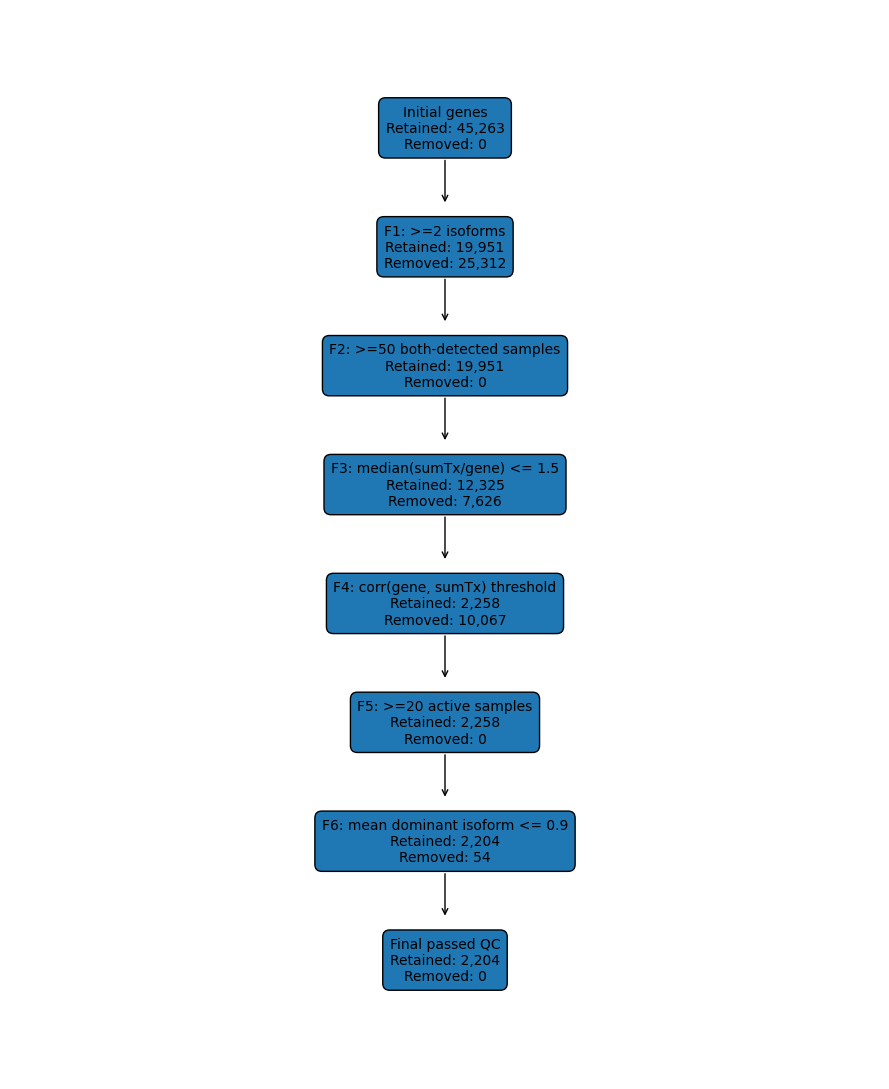

In [3]:
# -----------------------------
# Decision-tree style QC figure
# -----------------------------
def plot_qc_tree(attrition_df, setting, output_path):
    df = attrition_df[attrition_df["setting"] == setting].copy()

    labels = []
    for _, row in df.iterrows():
        labels.append(
            f"{row['filter']}\n"
            f"Retained: {row['retained']:,}\n"
            f"Removed: {row['removed_at_filter']:,}"
        )

    fig, ax = plt.subplots(figsize=(9, 11))
    ax.axis("off")

    y_positions = list(reversed(range(len(labels))))

    for i, (label, y) in enumerate(zip(labels, y_positions)):
        ax.text(
            0.5, y,
            label,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.5", linewidth=1),
            fontsize=10,
        )

        if i < len(labels) - 1:
            ax.annotate(
                "",
                xy=(0.5, y - 0.65),
                xytext=(0.5, y - 0.25),
                arrowprops=dict(arrowstyle="->", linewidth=1),
            )

    ax.set_ylim(-1, len(labels))
    ax.set_xlim(0, 1)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_qc_tree(
    attrition,
    setting="strict_corr_0.8",
    output_path=OUT_DIR / "qc_decision_tree_strict_corr08.png",
)

plot_qc_tree(
    attrition,
    setting="relaxed_corr_0.6",
    output_path=OUT_DIR / "qc_decision_tree_relaxed_corr06.png",
)

In [9]:
# -----------------------------
# Candidate good genes for dataset figure
# -----------------------------
good = qc[
    (qc["qc_pass_relaxed"] == True)
    & (qc["corr_gene_vs_sum_iso"] >= 0.9)
    & (qc["median_ratio_sumTx_to_gene"].between(0.75, 1.25))
    & (qc["mean_dominant_fraction"] <= 0.6)
    & (qc["mean_entropy"] >= 0.4)
].copy()

good = good.sort_values(
    by=["corr_gene_vs_sum_iso", "mean_entropy"],
    ascending=[False, False]
)

cols = [
    "gene_id",
    "n_isoforms",
    "corr_gene_vs_sum_iso",
    "median_ratio_sumTx_to_gene",
    "mean_dominant_fraction",
    "mean_entropy",
    "n_both_detected",
]

display(good[cols].head(50))

,gene_id,n_isoforms,corr_gene_vs_sum_iso,median_ratio_sumTx_to_gene,mean_dominant_fraction,mean_entropy,n_both_detected
1013,ATAD3B,6,1.000000,1.000000,0.453891,0.763354,19853
1170,SLC35E2A,4,1.000000,1.000000,0.517594,0.750822,19822
1167,LINC01770,4,1.000000,1.000000,0.522965,0.705082,11796
1092,C1QTNF12,5,1.000000,1.000000,0.498640,0.695430,18394
832,ZBTB48,8,1.000000,1.000000,0.460980,0.692732,19806
1165,HES4,4,1.000000,1.000000,0.545272,0.691472,18252
1020,LNCTAM34A,6,1.000000,1.000000,0.542146,0.603002,16452
759,FBXO44,9,1.000000,1.000000,0.484936,0.595000,19823
1019,LINC01134,6,1.000000,1.000000,0.526645,0.589643,19448
607,ENSG00000217801,11,1.000000,1.000000,0.430496,0.582298,19611


Selected gene: ATAD3B
Number of isoforms: 6
Transcript IDs: ['ENST00000673477', 'ENST00000308647', 'ENST00000472194', 'ENST00000378736', 'ENST00000485748', 'ENST00000474481']

Gene vs summed isoform ratio
Median ratio: 1.0
P10: 1.0
P90: 1.0


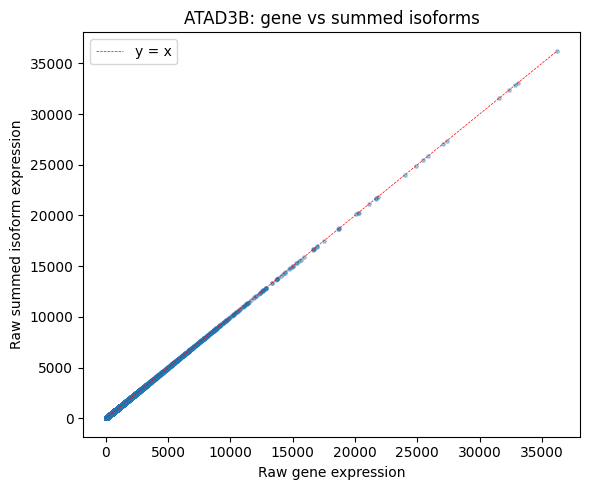

Saved: /work3/s252608/DL_project/results/qc_figures/ATAD3B_raw_gene_vs_sum_isoforms.png


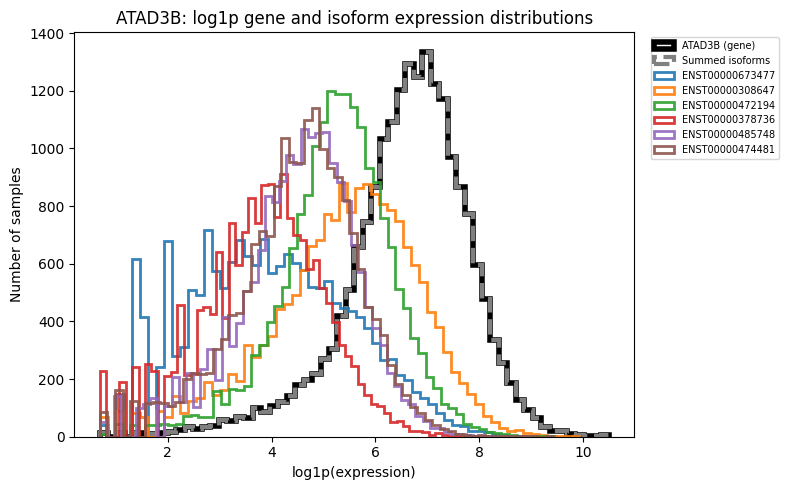

Saved: /work3/s252608/DL_project/results/qc_figures/ATAD3B_log1p_gene_and_isoform_distributions.png


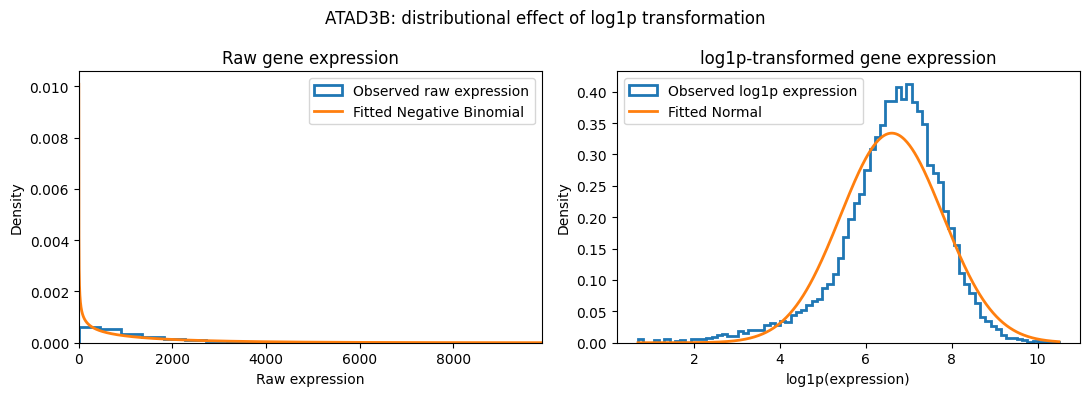

Saved: /work3/s252608/DL_project/results/qc_figures/ATAD3B_raw_nb_vs_log1p_normal_fit.png
NB fit: r=0.598, p=0.000458, mean=1305.835, var=2853452.740
Normal fit on log1p: mean=6.605, std=1.195


In [20]:
import json
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.sparse import issparse
from pathlib import Path
from scipy.stats import nbinom, norm

# -----------------------------
# Paths
# -----------------------------
RAW_GENE = "/work3/s252608/DL_project/data/raw/bulk_processed_genes.h5ad"
RAW_TX = "/work3/s252608/DL_project/data/raw/bulk_processed_transcripts.h5ad"
MAPPING = "/work3/s252608/DL_project/data/raw/bulk_processed_gene_to_transcripts.json"

OUT_DIR = Path("/work3/s252608/DL_project/results/qc_figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

ROW_BLOCK_SIZE = 256

# -----------------------------
# Select one readable good gene
# Requires `good` dataframe
# -----------------------------
readable_good = good[good["n_isoforms"].between(3, 8)].copy()

if readable_good.empty:
    raise ValueError("No good gene with 3–8 isoforms found.")

GENE_ID = readable_good.iloc[0]["gene_id"]

# -----------------------------
# Load backed AnnData
# -----------------------------
adata_gene = sc.read_h5ad(RAW_GENE, backed="r")
adata_tx = sc.read_h5ad(RAW_TX, backed="r")

with open(MAPPING, "r") as f:
    gene_to_tx = json.load(f)

tx_ids = [tx for tx in gene_to_tx[GENE_ID] if tx in adata_tx.var_names]

gene_idx = adata_gene.var_names.get_loc(GENE_ID)
tx_idx = [adata_tx.var_names.get_loc(tx) for tx in tx_ids]

print("Selected gene:", GENE_ID)
print("Number of isoforms:", len(tx_idx))
print("Transcript IDs:", tx_ids)

# -----------------------------
# Read data in blocks
# -----------------------------
g_list = []
sum_tx_list = []
tx_expr = {tx_id: [] for tx_id in tx_ids}

for start in range(0, adata_gene.n_obs, ROW_BLOCK_SIZE):
    end = min(start + ROW_BLOCK_SIZE, adata_gene.n_obs)

    g_block = adata_gene[start:end, gene_idx].X
    if issparse(g_block):
        g_block = g_block.toarray()

    g_block = np.asarray(g_block).reshape(-1).astype(np.float32)

    sum_tx_block = np.zeros(end - start, dtype=np.float32)

    for tx_id, tx_col in zip(tx_ids, tx_idx):
        tx_block = adata_tx[start:end, tx_col].X

        if issparse(tx_block):
            tx_block = tx_block.toarray()

        tx_block = np.asarray(tx_block).reshape(-1).astype(np.float32)

        tx_expr[tx_id].append(tx_block)
        sum_tx_block += tx_block

    g_list.append(g_block)
    sum_tx_list.append(sum_tx_block)

# -----------------------------
# Concatenate
# -----------------------------
g = np.concatenate(g_list)
sum_tx = np.concatenate(sum_tx_list)

for tx_id in tx_ids:
    tx_expr[tx_id] = np.concatenate(tx_expr[tx_id])

mask = (g > 0) | (sum_tx > 0)

# -----------------------------
# Quick QC stats
# -----------------------------
both = (g > 0) & (sum_tx > 0)
ratio = sum_tx[both] / g[both]

print("\nGene vs summed isoform ratio")
print("Median ratio:", np.median(ratio))
print("P10:", np.percentile(ratio, 10))
print("P90:", np.percentile(ratio, 90))

# =====================================================
# FIGURE 1
# Raw gene vs summed isoforms
# =====================================================
plt.figure(figsize=(6, 5))

plt.scatter(
    g[mask],
    sum_tx[mask],
    s=6,
    alpha=0.35,
)

max_val = max(g[mask].max(), sum_tx[mask].max())

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    linewidth=0.5,
    color="red",
    label="y = x"
)

plt.xlabel("Raw gene expression")
plt.ylabel("Raw summed isoform expression")
plt.title(f"{GENE_ID}: gene vs summed isoforms")
plt.legend()

plt.tight_layout()

save_path = OUT_DIR / f"{GENE_ID}_raw_gene_vs_sum_isoforms.png"
plt.savefig(save_path, dpi=300)
plt.show()

print("Saved:", save_path)

# =====================================================
# FIGURE 2
# log1p expression distributions
# =====================================================
plt.figure(figsize=(8, 5))

# Gene
gene_values = g[g > 0]

plt.hist(
    np.log1p(gene_values),
    bins=60,
    histtype="step",
    linewidth=4,
    color="black",
    label=f"{GENE_ID} (gene)",
)

# Summed isoforms
sum_values = sum_tx[sum_tx > 0]

plt.hist(
    np.log1p(sum_values),
    bins=60,
    histtype="step",
    linewidth=3,
    linestyle="--",
    color="gray",
    label="Summed isoforms",
)

# Individual isoforms
for tx_id in tx_ids:
    values = tx_expr[tx_id]
    values = values[values > 0]

    if len(values) < 20:
        continue

    plt.hist(
        np.log1p(values),
        bins=60,
        histtype="step",
        linewidth=2,
        alpha=0.9,
        label=tx_id,
    )

plt.xlabel("log1p(expression)")
plt.ylabel("Number of samples")
plt.title(f"{GENE_ID}: log1p gene and isoform expression distributions")
plt.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

save_path = OUT_DIR / f"{GENE_ID}_log1p_gene_and_isoform_distributions.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

# =====================================================
# FIGURE 3
# Raw vs log1p with fitted distributions
# =====================================================

gene_values = g[g > 0].astype(np.float64)
gene_log = np.log1p(gene_values)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# -----------------------------
# Left: raw expression + NB fit
# -----------------------------
ax = axes[0]

ax.hist(
    gene_values,
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="Observed raw expression",
)

# Method-of-moments NB fit
mean_raw = gene_values.mean()
var_raw = gene_values.var(ddof=1)

if var_raw <= mean_raw:
    raise ValueError(
        "Negative Binomial fit requires variance > mean. "
        "Raw data are not overdispersed enough for MOM NB."
    )

# NB parameterization:
# mean = r * (1 - p) / p
# var  = r * (1 - p) / p^2
p = mean_raw / var_raw
r = mean_raw**2 / (var_raw - mean_raw)

x_raw = np.arange(0, int(np.percentile(gene_values, 99.5)) + 1)

nb_pmf = nbinom.pmf(x_raw, r, p)

ax.plot(
    x_raw,
    nb_pmf,
    linewidth=2,
    label="Fitted Negative Binomial",
)

ax.set_title("Raw gene expression")
ax.set_xlabel("Raw expression")
ax.set_ylabel("Density")
ax.legend()

# Optional: avoid extreme tail dominating the plot
ax.set_xlim(0, np.percentile(gene_values, 99.5))

# -----------------------------
# Right: log1p expression + Normal fit
# -----------------------------
ax = axes[1]

ax.hist(
    gene_log,
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="Observed log1p expression",
)

mu_log = gene_log.mean()
std_log = gene_log.std(ddof=1)

x_log = np.linspace(gene_log.min(), gene_log.max(), 500)
normal_pdf = norm.pdf(x_log, loc=mu_log, scale=std_log)

ax.plot(
    x_log,
    normal_pdf,
    linewidth=2,
    label="Fitted Normal",
)

ax.set_title("log1p-transformed gene expression")
ax.set_xlabel("log1p(expression)")
ax.set_ylabel("Density")
ax.legend()

plt.suptitle(f"{GENE_ID}: distributional effect of log1p transformation")
plt.tight_layout()

save_path = OUT_DIR / f"{GENE_ID}_raw_nb_vs_log1p_normal_fit.png"
plt.savefig(save_path, dpi=300)
plt.show()

print("Saved:", save_path)
print(f"NB fit: r={r:.3f}, p={p:.6f}, mean={mean_raw:.3f}, var={var_raw:.3f}")
print(f"Normal fit on log1p: mean={mu_log:.3f}, std={std_log:.3f}")

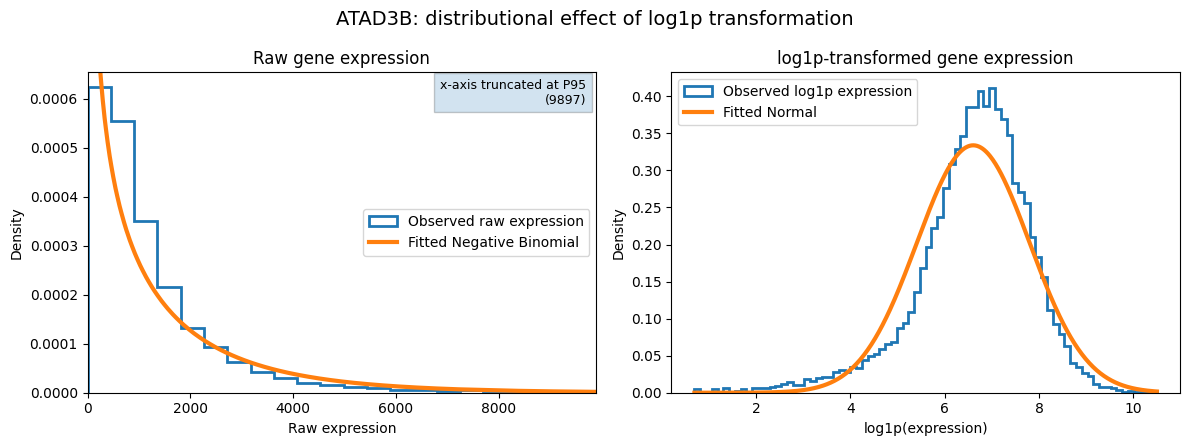

Saved: /work3/s252608/DL_project/results/qc_figures/ATAD3B_raw_nb_vs_log1p_normal_fit.png
NB fit → r=0.598, p=0.000458, mean=1305.835, var=2853452.740
Normal fit (log1p) → mean=6.605, std=1.195


In [32]:
from scipy.stats import nbinom, norm
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# FIGURE 3
# Raw vs log1p with fitted distributions
# =====================================================

gene_values = g[g > 0].astype(np.float64)
gene_log = np.log1p(gene_values)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# =====================================================
# LEFT: Raw expression + Negative Binomial fit
# =====================================================
ax = axes[0]

# Visual cutoff for readability
xmax = np.percentile(gene_values, 99.5)

# Histogram
hist_vals, bin_edges, _ = ax.hist(
    gene_values,
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="Observed raw expression",
)

# -----------------------------
# Negative Binomial fit
# -----------------------------
mean_raw = gene_values.mean()
var_raw = gene_values.var(ddof=1)

if var_raw <= mean_raw:
    raise ValueError(
        "Negative Binomial fit requires variance > mean."
    )

# Method-of-moments parameterization
p = mean_raw / var_raw
r = mean_raw**2 / (var_raw - mean_raw)

# Smooth x-grid
x_raw = np.linspace(0, xmax, 2000)

# Evaluate NB on nearest integers
x_int = np.round(x_raw).astype(int)
nb_curve = nbinom.pmf(x_int, r, p)

# Plot NB fit
ax.plot(
    x_raw,
    nb_curve,
    linewidth=3,
    label="Fitted Negative Binomial",
)

# -----------------------------
# Axis formatting
# -----------------------------
ax.set_xlim(0, xmax)

# Clip y-axis to avoid giant spike near zero
visible_ymax = np.percentile(hist_vals, 99)
ax.set_ylim(0, visible_ymax * 1.15)

ax.set_title("Raw gene expression")
ax.set_xlabel("Raw expression")
ax.set_ylabel("Density")
ax.legend()

# Annotation
ax.text(
    0.98,
    0.98,
    f"x-axis truncated at P95\n({xmax:.0f})",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(alpha=0.2)
)

# =====================================================
# RIGHT: log1p expression + Normal fit
# =====================================================
ax = axes[1]

# Histogram
ax.hist(
    gene_log,
    bins=80,
    density=True,
    histtype="step",
    linewidth=2,
    label="Observed log1p expression",
)

# -----------------------------
# Normal fit
# -----------------------------
mu_log = gene_log.mean()
std_log = gene_log.std(ddof=1)

x_log = np.linspace(gene_log.min(), gene_log.max(), 500)
normal_pdf = norm.pdf(
    x_log,
    loc=mu_log,
    scale=std_log,
)

# Plot Normal fit
ax.plot(
    x_log,
    normal_pdf,
    linewidth=3,
    label="Fitted Normal",
)

ax.set_title("log1p-transformed gene expression")
ax.set_xlabel("log1p(expression)")
ax.set_ylabel("Density")
ax.legend()

# =====================================================
# Final formatting
# =====================================================
plt.suptitle(
    f"{GENE_ID}: distributional effect of log1p transformation",
    fontsize=14
)

plt.tight_layout()

save_path = (
    OUT_DIR /
    f"{GENE_ID}_raw_nb_vs_log1p_normal_fit.png"
)

plt.savefig(save_path, dpi=300)
plt.show()

print("Saved:", save_path)

print(
    f"NB fit → "
    f"r={r:.3f}, "
    f"p={p:.6f}, "
    f"mean={mean_raw:.3f}, "
    f"var={var_raw:.3f}"
)

print(
    f"Normal fit (log1p) → "
    f"mean={mu_log:.3f}, "
    f"std={std_log:.3f}"
)


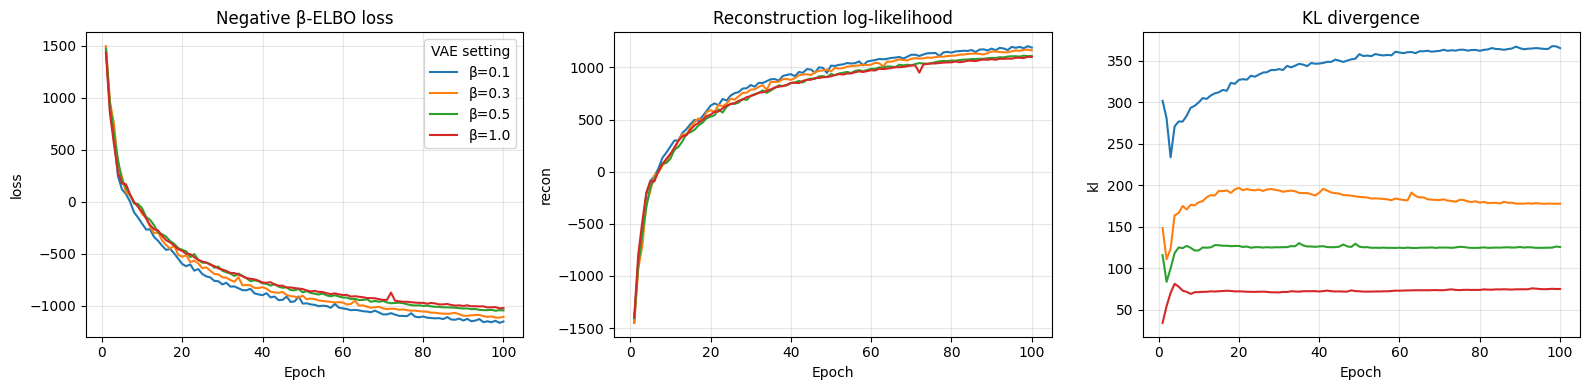

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

history_dir = Path("/work3/s252608/DL_project/results/vae_history")
files = sorted(history_dir.glob("bulk_vae_dim128_beta*.csv"))

histories = []

for f in files:
    df = pd.read_csv(f)
    beta = df["beta"].iloc[0]
    df["beta_label"] = f"β={beta}"
    histories.append(df)

history = pd.concat(histories, ignore_index=True)

metrics = ["loss", "recon", "kl"]
titles = ["Negative β-ELBO loss", "Reconstruction log-likelihood", "KL divergence"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

for ax, metric, title in zip(axes, metrics, titles):
    for beta_label, df_beta in history.groupby("beta_label"):
        ax.plot(df_beta["epoch"], df_beta[metric], label=beta_label)

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

axes[0].legend(title="VAE setting")

plt.tight_layout()
plt.savefig("/work3/s252608/DL_project/results/vae_history/vae_beta_training_curves.png", dpi=300)
plt.show()

,beta,mean_dim_std,median_dim_std,weak_dims,used_dims
0,0.1,0.436782,0.407448,0,128
1,0.3,0.405881,0.191823,15,113
2,0.5,0.346742,0.098733,67,61
3,1.0,0.253726,0.081955,103,25


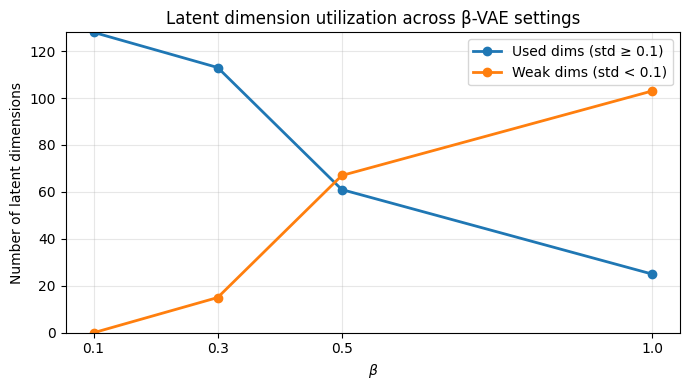

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

repr_dir = Path("/work3/s252608/DL_project/data/representations")
paths = sorted(repr_dir.glob("bulk_vae_dim128_beta*.npy"))

LATENT_DIM = 128
THRESHOLD = 0.10

rows = []

for p in paths:
    beta_str = p.stem.split("beta")[-1].replace("p", ".")
    beta = float(beta_str)

    Z = np.load(p)
    dim_std = Z.std(axis=0)

    weak_dims = np.sum(dim_std < THRESHOLD)
    used_dims = LATENT_DIM - weak_dims

    rows.append({
        "beta": beta,
        "mean_dim_std": dim_std.mean(),
        "median_dim_std": np.median(dim_std),
        "weak_dims": weak_dims,
        "used_dims": used_dims,
    })

summary = pd.DataFrame(rows).sort_values("beta")
display(summary)

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    summary["beta"],
    summary["used_dims"],
    marker="o",
    linewidth=2,
    label=f"Used dims (std ≥ {THRESHOLD})"
)

ax.plot(
    summary["beta"],
    summary["weak_dims"],
    marker="o",
    linewidth=2,
    label=f"Weak dims (std < {THRESHOLD})"
)

ax.set_xlabel(r"$\beta$")
ax.set_ylabel("Number of latent dimensions")
ax.set_title("Latent dimension utilization across β-VAE settings")

ax.set_xticks(summary["beta"])
ax.set_ylim(0, LATENT_DIM)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

# -------------------------
# Save
# -------------------------
out_path = Path(
    "/work3/s252608/DL_project/results/figures/vae_beta_utilization.png"
)

out_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    out_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Saved: {out_path}")

plt.show()